# Week 4 – Day 3: Attention-Based Spatial Modeling

## Objective

Develop an attention-based Graph Neural Network for property-price prediction.

The model will extend the baseline GraphSAGE approach by learning the relative importance of neighboring properties during message passing.

Geographic edge distance will also be incorporated as an edge feature so that the model can use both neighborhood relationships and physical proximity.

The attention-based model will be evaluated against the baseline GNN benchmark from Day 2.

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GATConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score,mean_absolute_percentage_error)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))

Using device: cpu


In [4]:
BASE_DIR = Path("..")

DATA_DIR = (BASE_DIR / "data" / "processed" / "week-3")

GNN_DIR = DATA_DIR / "gnn"

GRAPH_FILE = (GNN_DIR / "housing_graph_data.pt")

EDGE_FILE = (DATA_DIR / "final_graph_edges.csv")

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

ATTENTION_MODEL_FILE = (MODEL_DIR / "attention_gnn.pt")

HISTORY_FILE = (GNN_DIR / "attention_gnn_training_history.csv")

PREDICTION_FILE = (GNN_DIR / "attention_gnn_predictions.csv")

COMPARISON_FILE = (GNN_DIR / "gnn_model_comparison.csv")

In [5]:
graph_data = torch.load(GRAPH_FILE,weights_only=False)

print(graph_data)

Data(x=[21613, 24], edge_index=[2, 108065], y=[21613, 1], train_mask=[21613], val_mask=[21613], test_mask=[21613])


In [6]:
edges_df = pd.read_csv(EDGE_FILE)

print("Edge dataset:",edges_df.shape)

print(edges_df.head())

Edge dataset: (108065, 3)
   source  target  distance_km
0       0    6320     0.044478
1       0   16895     0.055597
2       0    5809     0.075925
3       0    2382     0.082181
4       0    5407     0.164361


In [7]:
assert len(edges_df) == (graph_data.edge_index.shape[1])

print("Graph edges:",graph_data.edge_index.shape[1])

print("CSV edges:",len(edges_df))

print("✅ Edge counts aligned.")

Graph edges: 108065
CSV edges: 108065
✅ Edge counts aligned.


In [8]:
edge_distance = edges_df["distance_km"].to_numpy()

assert np.isfinite(edge_distance).all()

assert (edge_distance >= 0).all()

edge_distance_log = np.log1p(edge_distance)

edge_scaler = StandardScaler()

edge_distance_scaled = (edge_scaler.fit_transform(edge_distance_log.reshape(-1, 1)).astype(np.float32))

edge_attr = torch.tensor(edge_distance_scaled,dtype=torch.float32)

print("Edge attribute shape:",edge_attr.shape)

Edge attribute shape: torch.Size([108065, 1])


In [9]:
graph_data = graph_data.to(device)
edge_attr = edge_attr.to(device)

print("Graph device:",graph_data.x.device)

print("Edge attribute device:",edge_attr.device)

Graph device: cpu
Edge attribute device: cpu


In [10]:
assert graph_data.num_nodes == 21613
assert graph_data.num_node_features == 24

assert graph_data.edge_index.shape == (2,108065)

assert edge_attr.shape == (108065,1)

assert graph_data.train_mask.sum().item() == 15129
assert graph_data.val_mask.sum().item() == 3242
assert graph_data.test_mask.sum().item() == 3242

print("✅ Attention model input validation passed.")

✅ Attention model input validation passed.


In [11]:
y_train_values = (graph_data.y[graph_data.train_mask].detach().cpu().numpy().reshape(-1))

y_mean = y_train_values.mean()
y_std = y_train_values.std()

assert y_std > 0

y_scaled = (graph_data.y - y_mean) / y_std

graph_data.y_scaled = y_scaled

print(f"Training target mean: ${y_mean:,.2f}")

print(f"Training target std: ${y_std:,.2f}")

Training target mean: $513,107.09
Training target std: $251,147.53


In [12]:
class AttentionGNN(nn.Module):

    def __init__(self,in_channels,hidden_channels=32,heads=4,dropout=0.2):
        super().__init__()
        self.gat1 = GATConv(in_channels=in_channels,out_channels=hidden_channels,heads=heads,concat=True,dropout=dropout,edge_dim=1)
        self.gat2 = GATConv(in_channels=hidden_channels * heads,out_channels=hidden_channels,heads=heads,concat=False,dropout=dropout,edge_dim=1)
        self.gat3 = GATConv(in_channels=hidden_channels,out_channels=hidden_channels,heads=heads,concat=False,dropout=dropout,edge_dim=1)
        self.regressor = nn.Sequential(nn.Linear(hidden_channels,32),nn.ReLU(),nn.Dropout(dropout),nn.Linear(32, 1))
        self.dropout = dropout

    def forward(self,x,edge_index,edge_attr):

        x = self.gat1(x,edge_index,edge_attr)
        x = F.elu(x)
        x = F.dropout(x,p=self.dropout,training=self.training)

        x = self.gat2(x,edge_index,edge_attr)
        x = F.elu(x)
        x = F.dropout(x,p=self.dropout,training=self.training)

        x = self.gat3(x,edge_index,edge_attr)
        x = F.elu(x)

        return self.regressor(x)

In [13]:
model = AttentionGNN(in_channels=graph_data.num_node_features,hidden_channels=32,heads=4,dropout=0.2).to(device)

print(model)

AttentionGNN(
  (gat1): GATConv(24, 32, heads=4)
  (gat2): GATConv(128, 32, heads=4)
  (gat3): GATConv(32, 32, heads=4)
  (regressor): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [14]:
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", f"{trainable_parameters:,}")

Trainable parameters: 26,369


In [15]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-5)

criterion = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss:", criterion)
print("✅ Attention GNN optimizer initialized.")

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)
Loss: MSELoss()
✅ Attention GNN optimizer initialized.


In [16]:
def calculate_metrics(y_true,y_pred):

    y_true = (y_true.detach().cpu().numpy().reshape(-1))
    y_pred = (y_pred.detach().cpu().numpy().reshape(-1))

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae = mean_absolute_error(y_true,y_pred)
    mape = (mean_absolute_percentage_error(y_true,y_pred) * 100)
    r2 = r2_score(y_true,y_pred)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

In [17]:
def train_one_epoch():

    model.train()
    optimizer.zero_grad()
    predictions_scaled = model(graph_data.x,graph_data.edge_index,edge_attr)
    loss = criterion(predictions_scaled[graph_data.train_mask],graph_data.y_scaled[graph_data.train_mask])
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)

    optimizer.step()

    return loss.item()

In [18]:
@torch.no_grad()
def evaluate():

    model.eval()
    predictions_scaled = model(graph_data.x,graph_data.edge_index,edge_attr)
    predictions = (predictions_scaled * y_std) + y_mean
    train_metrics = calculate_metrics(graph_data.y[graph_data.train_mask],predictions[graph_data.train_mask])
    val_metrics = calculate_metrics(graph_data.y[graph_data.val_mask],predictions[graph_data.val_mask])
    test_metrics = calculate_metrics(graph_data.y[graph_data.test_mask],predictions[graph_data.test_mask])

    return (predictions,train_metrics,val_metrics,test_metrics)

In [19]:
EPOCHS = 300
PATIENCE = 30

best_val_rmse = float("inf")
best_state = None
patience_counter = 0

history = []

for epoch in range(1,EPOCHS + 1):

    train_loss = (train_one_epoch())

    (predictions,train_metrics,val_metrics,test_metrics) = evaluate()

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_rmse": train_metrics["RMSE"],
        "val_rmse": val_metrics["RMSE"],
        "val_mape": val_metrics["MAPE"]
    })

    if (val_metrics["RMSE"] < best_val_rmse):
        best_val_rmse = (val_metrics["RMSE"])
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0

    else:
        patience_counter += 1

    if (epoch == 1 or epoch % 10 == 0):
        print(
            f"Epoch {epoch:03d} | "
            f"Loss: {train_loss:,.4f} | "
            f"Train RMSE: "
            f"${train_metrics['RMSE']:,.2f} | "
            f"Val RMSE: "
            f"${val_metrics['RMSE']:,.2f} | "
            f"Val MAPE: "
            f"{val_metrics['MAPE']:.2f}%"
        )

    if (patience_counter >= PATIENCE):
        print(f"\nEarly stopping at " f"epoch {epoch}.")
        break

Epoch 001 | Loss: 1.0015 | Train RMSE: $249,386.92 | Val RMSE: $250,034.29 | Val MAPE: 50.03%
Epoch 010 | Loss: 0.8417 | Train RMSE: $226,337.56 | Val RMSE: $227,269.30 | Val MAPE: 45.55%
Epoch 020 | Loss: 0.5412 | Train RMSE: $177,980.20 | Val RMSE: $179,953.93 | Val MAPE: 38.99%
Epoch 030 | Loss: 0.3942 | Train RMSE: $149,632.83 | Val RMSE: $151,486.84 | Val MAPE: 26.98%
Epoch 040 | Loss: 0.3728 | Train RMSE: $144,599.58 | Val RMSE: $144,885.39 | Val MAPE: 22.54%
Epoch 050 | Loss: 0.3438 | Train RMSE: $140,120.66 | Val RMSE: $140,842.05 | Val MAPE: 24.12%
Epoch 060 | Loss: 0.3342 | Train RMSE: $138,626.32 | Val RMSE: $139,094.11 | Val MAPE: 23.95%
Epoch 070 | Loss: 0.3286 | Train RMSE: $136,412.06 | Val RMSE: $136,746.71 | Val MAPE: 22.75%
Epoch 080 | Loss: 0.3209 | Train RMSE: $135,307.10 | Val RMSE: $135,438.18 | Val MAPE: 22.60%
Epoch 090 | Loss: 0.3169 | Train RMSE: $134,467.02 | Val RMSE: $134,677.98 | Val MAPE: 22.61%
Epoch 100 | Loss: 0.3152 | Train RMSE: $133,542.68 | Val RMS

In [20]:
assert best_state is not None

model.load_state_dict(best_state)

print("✅ Best attention model restored.")

print(f"Best validation RMSE: " f"${best_val_rmse:,.2f}")

✅ Best attention model restored.
Best validation RMSE: $124,760.92


In [21]:
(final_predictions,final_train_metrics,final_val_metrics,final_test_metrics) = evaluate()

print("=" * 60)
print("ATTENTION GNN FINAL RESULTS")
print("=" * 60)

print("\nTraining:")
print(f"RMSE: " f"${final_train_metrics['RMSE']:,.2f}")
print(f"MAPE: " f"{final_train_metrics['MAPE']:.2f}%")
print(f"R²: " f"{final_train_metrics['R2']:.4f}")

print("\nValidation:")
print(f"RMSE: " f"${final_val_metrics['RMSE']:,.2f}")
print(f"MAPE: " f"{final_val_metrics['MAPE']:.2f}%")
print(f"R²: " f"{final_val_metrics['R2']:.4f}")

print("\nTest:")
print(f"RMSE: " f"${final_test_metrics['RMSE']:,.2f}")
print(f"MAPE: " f"{final_test_metrics['MAPE']:.2f}%")
print(f"R²: " f"{final_test_metrics['R2']:.4f}")

ATTENTION GNN FINAL RESULTS

Training:
RMSE: $123,149.38
MAPE: 19.67%
R²: 0.7596

Validation:
RMSE: $124,760.92
MAPE: 20.42%
R²: 0.7544

Test:
RMSE: $121,562.18
MAPE: 19.40%
R²: 0.7490


In [22]:
BASELINE_GNN_MAPE = 12.32
BASELINE_GNN_RMSE = 80285.81
BASELINE_GNN_R2 = 0.8905

attention_mape = final_test_metrics["MAPE"]
attention_rmse = final_test_metrics["RMSE"]
attention_r2 = final_test_metrics["R2"]

mape_change = ((attention_mape - BASELINE_GNN_MAPE) / BASELINE_GNN_MAPE) * 100

rmse_change = ((attention_rmse - BASELINE_GNN_RMSE) / BASELINE_GNN_RMSE) * 100

print(f"Baseline GNN MAPE: " f"{BASELINE_GNN_MAPE:.2f}%")

print(f"Attention GNN MAPE: " f"{attention_mape:.2f}%")

print(f"MAPE degradation: " f"{mape_change:.2f}%")

print(f"Baseline GNN RMSE: " f"${BASELINE_GNN_RMSE:,.2f}")

print(f"Attention GNN RMSE: " f"${attention_rmse:,.2f}")

print(f"RMSE degradation: " f"{rmse_change:.2f}%")

print(f"Baseline GNN R²: " f"{BASELINE_GNN_R2:.4f}")

print(f"Attention GNN R²: " f"{attention_r2:.4f}")

Baseline GNN MAPE: 12.32%
Attention GNN MAPE: 19.40%
MAPE degradation: 57.44%
Baseline GNN RMSE: $80,285.81
Attention GNN RMSE: $121,562.18
RMSE degradation: 51.41%
Baseline GNN R²: 0.8905
Attention GNN R²: 0.7490


In [23]:
history_df = pd.DataFrame(history)

history_df.to_csv(HISTORY_FILE,index=False)

print("✅ Attention training history saved.")

✅ Attention training history saved.


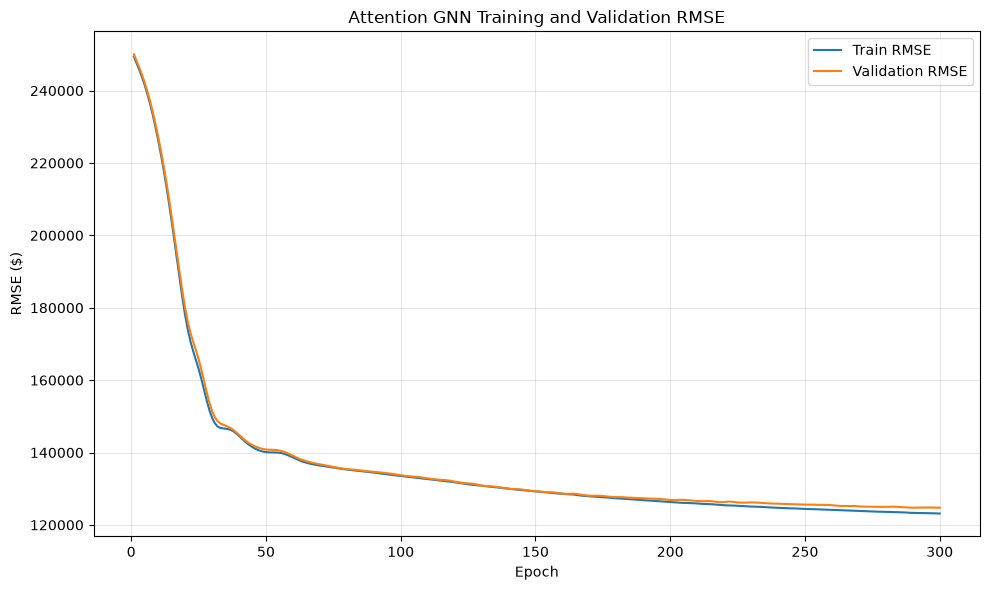

✅ Saved: ..\data\processed\week-3\gnn\attention_gnn_training_curve.png


In [24]:
curve_path = (GNN_DIR / "attention_gnn_training_curve.png")

plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"],history_df["train_rmse"],label="Train RMSE")

plt.plot(history_df["epoch"],history_df["val_rmse"],label="Validation RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE ($)")
plt.title("Attention GNN Training and Validation RMSE")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(curve_path,dpi=150,bbox_inches="tight")

plt.show()

print("✅ Saved:",curve_path)

In [25]:
node_ids = np.arange(graph_data.num_nodes)

attention_prediction_df = pd.DataFrame({
    "node_id": node_ids,
    "actual_price": (graph_data.y.cpu().numpy().reshape(-1)),
    "predicted_price": (final_predictions.cpu().numpy().reshape(-1))
})

attention_prediction_df["absolute_error"] = (attention_prediction_df["actual_price"] - attention_prediction_df["predicted_price"]).abs()

attention_prediction_df["percentage_error"] = (attention_prediction_df["absolute_error"] / attention_prediction_df["actual_price"]) * 100

attention_prediction_df.to_csv(PREDICTION_FILE,index=False)

print("✅ Attention predictions saved.")

✅ Attention predictions saved.


In [26]:
comparison_df = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Baseline GNN",
        "Attention GNN"
    ],
    "Test RMSE": [
        103398.17,
        BASELINE_GNN_RMSE,
        attention_rmse
    ],
    "Test MAPE": [
        17.31,
        BASELINE_GNN_MAPE,
        attention_mape
    ],
    "Test R2": [
        0.8274,
        BASELINE_GNN_R2,
        attention_r2
    ]
})

comparison_df

,Model,Test RMSE,Test MAPE,Test R2
0,XGBoost,103398.17000,17.310000,0.827400
1,Baseline GNN,80285.81000,12.320000,0.890500
2,Attention GNN,121562.17517,19.396721,0.748952


In [27]:
comparison_df.to_csv(COMPARISON_FILE,index=False)

print("✅ Model comparison saved:")
print(COMPARISON_FILE)

✅ Model comparison saved:
..\data\processed\week-3\gnn\gnn_model_comparison.csv


In [28]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_class": "AttentionGNN",
        "input_features": graph_data.num_node_features,
        "hidden_channels": 32,
        "heads": 4,
        "dropout": 0.2,
        "seed": SEED,
        "best_val_rmse": best_val_rmse,
        "target_mean": float(y_mean),
        "target_std": float(y_std),
        "edge_mean": float(edge_scaler.mean_[0]),
        "edge_scale": float(edge_scaler.scale_[0])
    },
    ATTENTION_MODEL_FILE
)

print("✅ Attention GNN model saved:")
print(ATTENTION_MODEL_FILE)

✅ Attention GNN model saved:
..\models\attention_gnn.pt


In [30]:
assert len(attention_prediction_df) == graph_data.num_nodes

assert (attention_prediction_df["predicted_price"].notna().all())

assert np.isfinite(attention_prediction_df["predicted_price"]).all()

assert (history_df["val_rmse"].notna().all())

assert os.path.exists(ATTENTION_MODEL_FILE)

assert os.path.exists(PREDICTION_FILE)

assert os.path.exists(COMPARISON_FILE)

print("=" * 60)
print("WEEK 4 DAY 3 VALIDATION")
print("=" * 60)

print(f"Test RMSE: " f"${attention_rmse:,.2f}")

print(f"Test MAPE: " f"{attention_mape:.2f}%")

print(f"Test R²: " f"{attention_r2:.4f}")

print(f"MAPE degradation vs baseline GNN: " f"{mape_change:.2f}%")

print("\n✅ Attention GNN validation passed.")

WEEK 4 DAY 3 VALIDATION
Test RMSE: $121,562.18
Test MAPE: 19.40%
Test R²: 0.7490
MAPE degradation vs baseline GNN: 57.44%

✅ Attention GNN validation passed.
